# A Weather Model made using XGBoost

A not so simple weather moden making use of Chained Multi-output regression using XGBOOSt

In [1]:
import sys
!{sys.executable} -m pip install xgboost
%pip install shap


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()

weather = pd.read_csv("Refined Datasets/All_Cleaned_Data.csv",index_col=1, encoding='latin1' )
weather.head(10)

,name,humidity,precip,precipcover,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,sunrise,sunset,tempmax c,tempmin c,avgtemp c,feelslikemax c,feelslikemin c,avgfeelsliketemp c,dewpoint c
datetime,,,,,,,,,,,,,,,,,,,,
2005-01-01,Arima,92.8,33.6296,12.50,10.3,70.6,1013.4,87.1,6.4,197.341176,17.052941,23007,64462,29.0,24.1,25.4,34.6,24.1,26.2,24.1
2005-01-02,Arima,78.9,6.1722,4.17,13.8,40.1,1013.2,64.6,7.8,209.823529,18.170588,23031,64495,32.0,23.1,26.6,34.2,23.1,27.5,22.1
2005-01-03,Arima,81.5,0.4826,4.17,8.1,62.6,1012.6,54.8,8.4,219.517647,18.964706,23053,64527,31.8,22.1,25.5,34.0,22.1,26.4,21.8
2005-01-04,Arima,93.2,12.1666,12.50,11.4,67.1,1011.6,83.1,6.8,209.488235,18.147059,23075,64560,29.2,23.1,24.6,33.7,23.1,25.1,23.3
2005-01-05,Arima,83.2,0.7874,4.17,4.7,50.1,1012.7,77.9,16.8,196.450000,16.975000,23096,64593,31.3,23.7,25.1,33.4,23.7,25.3,21.8
2005-01-06,Arima,83.2,2.1590,4.17,10.3,67.5,1010.8,92.5,9.8,188.668750,16.312500,23116,64625,30.2,24.6,26.6,34.7,24.6,27.7,23.3
2005-01-07,Arima,90.5,10.7950,8.33,16.1,73.2,1010.8,95.0,4.4,190.000000,16.362500,23136,64658,27.1,23.1,24.9,30.4,23.1,25.7,23.2
2005-01-08,Arima,81.3,8.8138,4.17,10.3,78.7,1011.9,90.0,10.0,201.762500,17.418750,23154,64690,29.2,24.1,26.4,32.7,24.1,28.0,22.7
2005-01-09,Arima,78.5,0.0000,0.00,12.8,82.9,1011.6,81.6,9.5,194.062500,16.775000,23172,64722,30.1,23.7,27.3,34.2,23.7,29.5,23.1


In [3]:
#Unique locations
print("Unique locations:", weather['name'].nunique())

Unique locations: 18


In [4]:
weather.apply(pd.isnull).sum()  # Check for missing values in the DataFrame, everything should be 0

name                  0
humidity              0
precip                0
precipcover           0
windspeed             0
winddir               0
sealevelpressure      0
cloudcover            0
visibility            0
solarradiation        0
solarenergy           0
sunrise               0
sunset                0
tempmax c             0
tempmin c             0
avgtemp c             0
feelslikemax c        0
feelslikemin c        0
avgfeelsliketemp c    0
dewpoint c            0
dtype: int64

In [5]:
weather.dtypes   #verify the data types of each column

name                   object
humidity              float64
precip                float64
precipcover           float64
windspeed             float64
winddir               float64
sealevelpressure      float64
cloudcover            float64
visibility            float64
solarradiation        float64
solarenergy           float64
sunrise                 int64
sunset                  int64
tempmax c             float64
tempmin c             float64
avgtemp c             float64
feelslikemax c        float64
feelslikemin c        float64
avgfeelsliketemp c    float64
dewpoint c            float64
dtype: object

In [6]:
weather.index

Index(['2005-01-01', '2005-01-02', '2005-01-03', '2005-01-04', '2005-01-05',
       '2005-01-06', '2005-01-07', '2005-01-08', '2005-01-09', '2005-01-10',
       ...
       '2026-05-08', '2026-05-09', '2026-05-10', '2026-05-11', '2026-05-12',
       '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-16', '2026-05-17'],
      dtype='object', name='datetime', length=123970)

In [7]:
weather.index = pd.to_datetime(weather.index)   # Convert index to datetime if not already
weather.index

DatetimeIndex(['2005-01-01', '2005-01-02', '2005-01-03', '2005-01-04',
               '2005-01-05', '2005-01-06', '2005-01-07', '2005-01-08',
               '2005-01-09', '2005-01-10',
               ...
               '2026-05-08', '2026-05-09', '2026-05-10', '2026-05-11',
               '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15',
               '2026-05-16', '2026-05-17'],
              dtype='datetime64[ns]', name='datetime', length=123970, freq=None)

# Train Test Split

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
weather['location_encoded'] = le.fit_transform(weather['name'])

weather.columns

Index(['name', 'humidity', 'precip', 'precipcover', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation',
       'solarenergy', 'sunrise', 'sunset', 'tempmax c', 'tempmin c',
       'avgtemp c', 'feelslikemax c', 'feelslikemin c', 'avgfeelsliketemp c',
       'dewpoint c', 'location_encoded'],
      dtype='object')

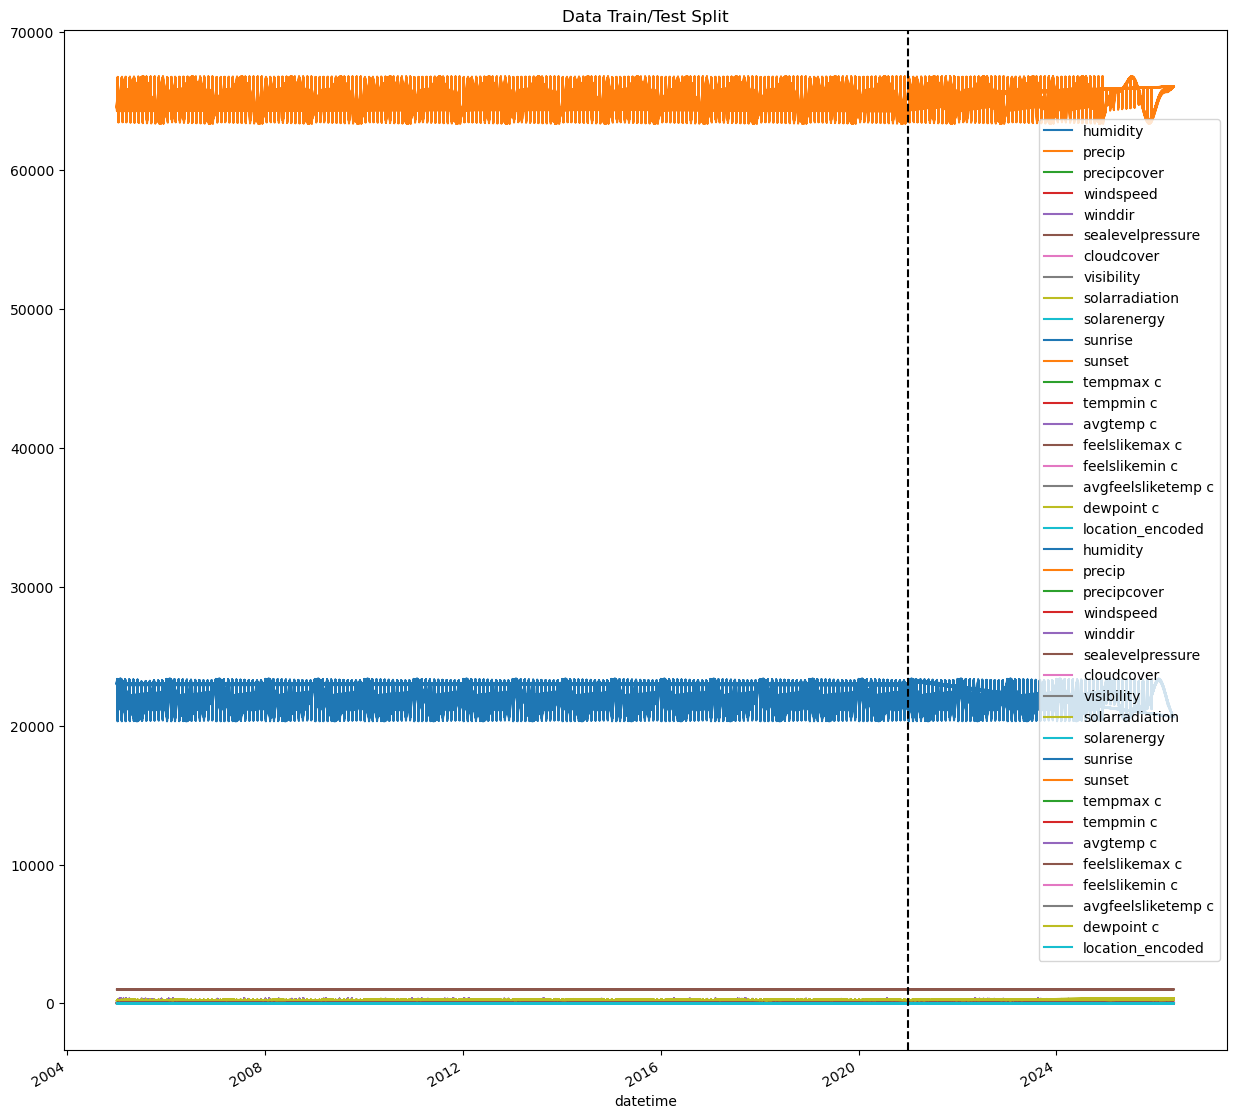

In [9]:
train = weather.loc[weather.index < '01-01-2021']
test = weather.loc[weather.index > '01-01-2021']

fig, ax = plt.subplots(figsize=(15, 15))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Spuet')
ax.axvline('01-01-2021', color='black', ls='--')
plt.show()

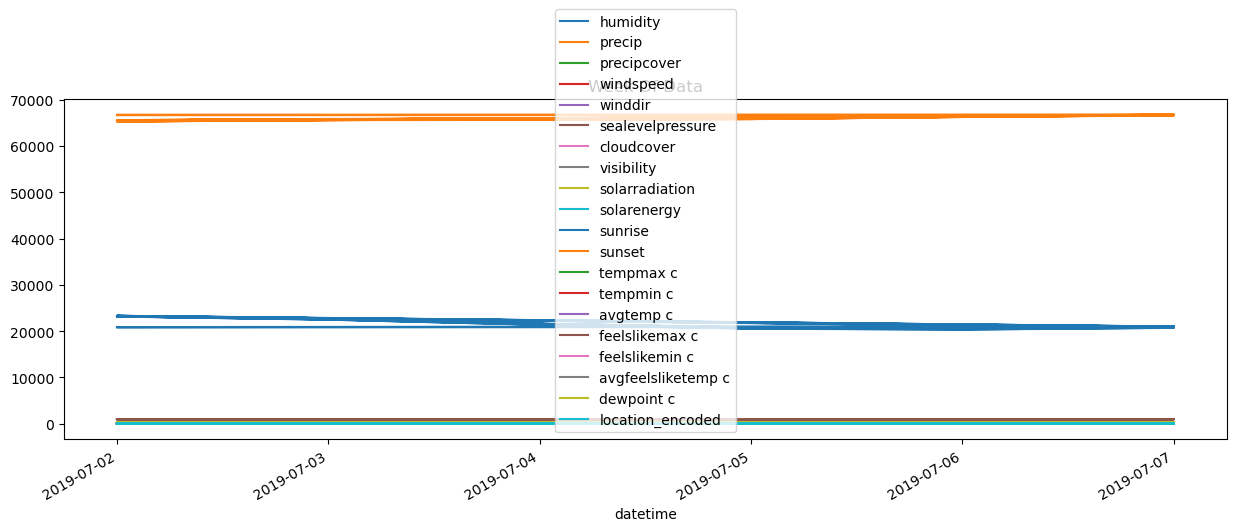

In [10]:
weather.loc[(weather.index > '07-01-2019') & (weather.index < '07-08-2019')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()

# Create features 

In [11]:
df = weather.copy()
df['dayofweek'] = df.index.dayofweek
df['dayofyear'] = df.index.dayofyear
df['month'] = df.index.month
df['year'] = df.index.year

In [12]:
print(weather.columns)
def create_features(df):
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['dayofyear'] = df.index.dayofyear
    df['month'] = df.index.month
    df['year'] = df.index.year
    
    return df
df = create_features(weather)


Index(['name', 'humidity', 'precip', 'precipcover', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation',
       'solarenergy', 'sunrise', 'sunset', 'tempmax c', 'tempmin c',
       'avgtemp c', 'feelslikemax c', 'feelslikemin c', 'avgfeelsliketemp c',
       'dewpoint c', 'location_encoded'],
      dtype='object')


In [13]:
df.tail(10)

,name,humidity,precip,precipcover,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,...,avgtemp c,feelslikemax c,feelslikemin c,avgfeelsliketemp c,dewpoint c,location_encoded,dayofweek,dayofyear,month,year
datetime,,,,,,,,,,,,,,,,,,,,,
2026-05-08,San Fernando,65.1,0.1016,0.00,16.1,109.3,1012.0,12.4,6.2,241.1,...,27.9,33.7,26.0,29.0,20.6,11,4,128,5,2026
2026-05-09,San Fernando,67.3,0.0000,0.00,19.6,111.9,1012.5,16.8,6.2,287.6,...,27.4,33.5,23.0,28.4,20.4,11,5,129,5,2026
2026-05-10,San Fernando,68.1,0.7112,4.17,19.6,103.5,1013.5,14.0,6.2,262.5,...,27.9,34.2,25.0,29.4,21.3,11,6,130,5,2026
2026-05-11,San Fernando,70.1,0.6096,4.17,25.3,104.5,1013.3,14.9,6.0,281.6,...,28.1,34.9,25.0,30.0,21.9,11,0,131,5,2026
2026-05-12,San Fernando,71.0,0.1016,0.00,19.6,110.9,1014.2,19.4,5.8,268.3,...,28.4,34.6,26.0,30.7,22.4,11,1,132,5,2026
2026-05-13,San Fernando,72.6,0.2032,0.00,17.2,113.8,1014.9,26.2,6.1,226.3,...,27.9,34.6,25.9,30.1,22.4,11,2,133,5,2026
2026-05-14,San Fernando,71.1,0.3048,0.00,20.8,110.7,1014.8,36.0,5.8,263.5,...,27.9,34.8,24.9,29.6,21.9,11,3,134,5,2026
2026-05-15,San Fernando,74.9,2.0320,20.83,19.7,108.4,1014.4,44.3,5.9,290.4,...,28.0,35.7,25.9,30.6,22.9,11,4,135,5,2026
2026-05-16,San Fernando,76.4,0.3048,0.00,24.2,115.1,1014.2,59.1,5.4,285.5,...,27.8,35.4,25.9,29.9,23.1,11,5,136,5,2026


In [14]:
location_range = df['location_encoded'].unique()
print(len(location_range))
print(location_range)

18
[ 0 11  1  2 16  3  4  5  7  8  9 10 12 13 14 15  6 17]


In [15]:
train = create_features(train)
test = create_features(test)

# XGBoost Model: Chained Multi-Output Regression Model


Heres where the fun begins, and my pain starts. This is where hte models are actually trained. THe initial training was done on a small subset of the data, that was since exmpanded to encompass the remaining variables. A dedicated greedy analysis would be nice, but instead I eye balled the inital variables and starting point:   Greedy_Features were eyeballed based of the heatmap diagram. Temp_Based also used a function of that diagram but tune daround temp. Precip based  also used a function of that diagram but tuned around precip. Time based  also used a function of that diagram but tuned around timed scaled values.

Heres where it gets even worse. I spent 3 days trying to encompass the methods to make, test and tune the model into individual functions which would allow for all to be run and tuned in one go. Instead, I spent 3 days of hair pulling and head scratching and for some reason they refuse to play ball, so have a smiley face instead :D

In [16]:
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
features_only = df.copy()
features_only = features_only.drop(columns=['location_encoded', 'dayofweek', 'dayofyear', 'month', 'year','name'])

#features used to build the model
core_features = ['location_encoded', 'dayofweek', 'dayofyear', 'month', 'year']

base_features =features_only.columns
length= len(base_features)
print("Base features length:", length)
print("Base features:", base_features)

Base features length: 19
Base features: Index(['humidity', 'precip', 'precipcover', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation',
       'solarenergy', 'sunrise', 'sunset', 'tempmax c', 'tempmin c',
       'avgtemp c', 'feelslikemax c', 'feelslikemin c', 'avgfeelsliketemp c',
       'dewpoint c'],
      dtype='object')


In [18]:
greedy_features = [
    'dewpoint c',         # strong with humidity (0.68), avgtemp, feelsliketemp
    'humidity',
    'avgtemp c',
    'feelslikemax c',
    'feelslikemin c',
    'avgfeelsliketemp c',
    'tempmax c',
    'tempmin c',
    'precipcover',
    'precip',
    'solarradiation',
    'solarenergy',
    'sealevelpressure',
    'cloudcover',
    'sunrise',
    'sunset',
    'visibility',
    'windspeed',
    'winddir'
]


In [19]:
temp_based=[
    'cloudcover',
    'avgtemp c',
    'tempmax c',
    'tempmin c',
    'feelslikemax c',
    'feelslikemin c',
    'avgfeelsliketemp c',
    'humidity',
    'dewpoint c',
    'precipcover',
    'precip',
    'sealevelpressure',
    'solarradiation',
    'solarenergy',
    'sunrise',
    'sunset',
    'visibility',
    'windspeed',
    'winddir'
]


In [20]:
precip_based=[
    'humidity',
    'dewpoint c',
    'precip',
    'precipcover',
    'cloudcover',
    'sealevelpressure',
    'avgtemp c',
    'feelslikemax c',
    'feelslikemin c',
    'avgfeelsliketemp c',
    'tempmax c',
    'tempmin c',
    'solarradiation',
    'solarenergy',
    'sunrise',
    'sunset',
    'windspeed',
    'winddir',
    'visibility'
]


In [21]:
time_based=[
    'sunrise',
    'sunset',
    'solarradiation',
    'solarenergy',
    'cloudcover',
    'visibility',
    'humidity',
    'dewpoint c',
    'avgtemp c',
    'feelslikemax c',
    'feelslikemin c',
    'avgfeelsliketemp c',
    'tempmax c',
    'tempmin c',
    'precipcover',
    'precip',
    'sealevelpressure',
    'windspeed',
    'winddir'
]


In [22]:
hurestic_evaluation=[
    'humidity',             # high correlation with dewpoint
    'dewpoint c',
    'avgtemp c',
    'feelslikemax c',
    'avgfeelsliketemp c',
    'tempmax c',
    'feelslikemin c',
    'tempmin c',
    'precipcover',
    'precip',
    'cloudcover',
    'solarradiation',
    'solarenergy',
    'sunset',
    'sunrise',
    'sealevelpressure',
    'windspeed',
    'visibility',
    'winddir'
]


In [23]:
inital_features = ['cloudcover', 'precip','humidity', 'windspeed','feelslikemax c','tempmax c', 'tempmin c', 
                'avgtemp c','feelslikemin c', 'avgfeelsliketemp c','dewpoint c', 'visibility']


In [24]:
# Columns to predict
target_features= temp_based

#blank DataFrame for the model predictions
predictions = pd.DataFrame(index=df.index)

#Dict to store each model
models = {}

In [25]:
def train_model(df, target, core_features, prev_predictions=None, models={}):
   
    X = df[core_features]
    y = df[target].astype(float).values.ravel()

    print(f"\n Training model to predict: {target}")
    
    if prev_predictions is not None:
        prev_predictions = prev_predictions.loc[:, ~prev_predictions.columns.isin(X.columns)]
        X = pd.concat([X, prev_predictions], axis=1)

    model = xgb.XGBRegressor(
    n_estimators=1500,
    max_depth=6,
    eta=0.03,
    learning_rate=0.03,
    subsample=0.8,
)
    model.fit(X, y)
    
    y_pred = model.predict(X)

    print(f"{target} MAE: {mean_absolute_error(y, y_pred):.3f}")

    joblib.dump(model, f"Models/{target}_model.pkl", compress=6)
    print(f"Model Saved")

    models[target] = model

    return y_pred


In [26]:
for i, target in enumerate(target_features):
    prev = predictions if i > 0 else None
    y_pred = train_model(df, target, core_features, prev, models)
    predictions[f'pred_{target}'] = y_pred


 Training model to predict: cloudcover


cloudcover MAE: 6.485
Model Saved

 Training model to predict: avgtemp c
avgtemp c MAE: 0.426
Model Saved

 Training model to predict: tempmax c
tempmax c MAE: 0.522
Model Saved

 Training model to predict: tempmin c
tempmin c MAE: 0.438
Model Saved

 Training model to predict: feelslikemax c
feelslikemax c MAE: 0.738
Model Saved

 Training model to predict: feelslikemin c
feelslikemin c MAE: 0.320
Model Saved

 Training model to predict: avgfeelsliketemp c
avgfeelsliketemp c MAE: 0.404
Model Saved

 Training model to predict: humidity
humidity MAE: 1.697
Model Saved

 Training model to predict: dewpoint c
dewpoint c MAE: 0.227
Model Saved

 Training model to predict: precipcover
precipcover MAE: 2.504
Model Saved

 Training model to predict: precip
precip MAE: 2.284
Model Saved

 Training model to predict: sealevelpressure
sealevelpressure MAE: 0.513
Model Saved

 Training model to predict: solarradiation
solarradiation MAE: 14.268
Model Saved

 Training model to predict: solarenergy


In [27]:
def predict_for_date(input_df, models, target_order):
    input_copy = input_df.copy()
    preds = {}

    for target in target_order:
        model = models[target]
        prediction = model.predict(input_copy)
        preds[target] = prediction
        input_copy[f'pred_{target}'] = prediction

    return preds

In [28]:
from datetime import datetime

def prepare_input_from_date(date_str, location_encoded):
    dt = datetime.strptime(date_str, "%d-%m-%Y")
    return pd.DataFrame([{
        'location_encoded': location_encoded,
        'dayofweek': dt.weekday(),
        'dayofyear': dt.timetuple().tm_yday,
        'month': dt.month,
        'year': dt.year
    }])

In [29]:
def print_predictions(preds):
    print("Predictions:")
    for key, val in preds.items():
        print(f"{key:<20}: {val[0]:.2f}")

In [30]:
#dd-mm-yyyy
date_str = "05-07-2025"
location_encoded = 10
input_df = prepare_input_from_date(date_str, location_encoded)
preds = predict_for_date(input_df, models, target_features)

print_predictions(preds)

Predictions:
cloudcover          : 59.23
avgtemp c           : 26.97
tempmax c           : 31.36
tempmin c           : 24.05
feelslikemax c      : 38.56
feelslikemin c      : 23.85
avgfeelsliketemp c  : 30.36
humidity            : 85.63
dewpoint c          : 24.57
precipcover         : 2.60
precip              : 0.19
sealevelpressure    : 1015.02
solarradiation      : 223.94
solarenergy         : 18.99
sunrise             : 20819.76
sunset              : 66540.20
visibility          : 7.53
windspeed           : 13.47
winddir             : 109.59


In [31]:

# for target, model in models.items():
#     fi = pd.DataFrame(data=model.feature_importances_, index=model.feature_names_in_, columns=['importance'])
#     fi = fi.sort_values('importance', ascending=True)
#     fi.plot(kind='barh', title=f'Feature Importance for {target}')
#     plt.xlabel("Importance")
#     plt.tight_layout()
#     plt.show()


In [32]:
from sklearn.metrics import mean_absolute_error

predictions = pd.DataFrame(index=df.index)
accuracies = []
accuracy_result = []

for target in models.keys():
    model = models[target]

    # Base features
    X = df[core_features].copy()

    # Adding prior predictions
    if not predictions.empty:
        X = pd.concat([X, predictions], axis=1)

    # Match model's expected features
    model_features = model.feature_names_in_
    X = X[model_features]

    # Predict
    y_true = df[target].astype(float).values.ravel()
    y_pred = model.predict(X)

    # Save prediction
    predictions[f'pred_{target}'] = y_pred

    # Calculate accuracy based on MAE relative to y_true range
    mae = mean_absolute_error(y_true, y_pred)
    value_range = y_true.max() - y_true.min()
    if value_range == 0:
        accuracy = 100.0  # avoid divide-by-zero
    else:
        accuracy = 100 - ((mae / value_range) * 100)

    accuracies.append(accuracy)
    result = (f"{target} Accuracy: {accuracy:.2f}%")
    accuracy_result.append(result)
    print (result)

# Average across all targets
avg_accuracy = sum(accuracies) / len(accuracies)
print(f"\nAverage Accuracy Across Models: {avg_accuracy:.2f}%")

cloudcover Accuracy: 92.79%
avgtemp c Accuracy: 94.81%
tempmax c Accuracy: 96.19%
tempmin c Accuracy: 96.63%
feelslikemax c Accuracy: 97.88%
feelslikemin c Accuracy: 98.36%
avgfeelsliketemp c Accuracy: 97.58%
humidity Accuracy: 95.97%
dewpoint c Accuracy: 97.73%
precipcover Accuracy: 97.50%
precip Accuracy: 99.03%
sealevelpressure Accuracy: 95.29%
solarradiation Accuracy: 96.29%
solarenergy Accuracy: 97.07%
sunrise Accuracy: 97.19%
sunset Accuracy: 97.57%
visibility Accuracy: 98.47%
windspeed Accuracy: 99.04%
winddir Accuracy: 98.01%

Average Accuracy Across Models: 97.02%


In [33]:
import os

output_dir= 'models/'

# Create a report file to log the CSV files found in the directory
if not os.path.exists('models/report.txt'):
    report_file = open('models/report.txt', 'x')
 
else:
    report_file = open('models/report.txt', 'w')

report_file.write("Report of All models: \n")


for item in accuracy_result:
    report_file.write((f"{item}\n"))

report_file.write(f"\nAverage Accuracy Across Models: {avg_accuracy:.2f}% \n")


report_file.close()


In [34]:
# import matplotlib.pyplot as plt

# for target in target_features:
#     y_true = df[target].astype(float).values.ravel()
#     y_pred = predictions[f'pred_{target}']

#     plt.figure(figsize=(10, 6))
#     plt.scatter(y_true, y_pred, alpha=0.5, label='Predicted vs Actual', color='#399660')
#     plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal Fit')
#     plt.xlabel('Actual Values')
#     plt.ylabel('Predicted Values')
#     plt.title(f'Predicted vs Actual for {target}')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

